In [ ]:
!pip install -q transformers>=4.45.0 peft>=0.13.0 accelerate>=0.34.0 datasets>=2.19.0
!pip install -q "torchao>=0.16.0" --upgrade
!pip install -q "peft>=0.13.0" --upgrade
!pip install -q transformers>=4.45.0 accelerate>=0.34.0 datasets>=2.19.0

In [ ]:
# Cell 2 - Upload Data and Prepare Dataset
from google.colab import files
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

#print('Upload your scenario23_clean.csv file...')
#uploaded = files.upload()

df = pd.read_csv('scenario23_clean.csv')

FEATURE_COLS = [
    'unit2_gps_lat', 'unit2_gps_long',
    'pwr_max', 'pwr_mean', 'pwr_std',
    'pwr_median', 'pwr_top3_mean', 'pwr_range'
]
LABEL_COL  = 'unit1_beam_index'
LABEL_TOP2 = 'unit1_beam_top2'
LABEL_TOP3 = 'unit1_beam_top3'
N_BEAMS    = 64
N_FEATURES = len(FEATURE_COLS)

df = df[FEATURE_COLS + [LABEL_COL, LABEL_TOP2, LABEL_TOP3]].dropna()

X      = df[FEATURE_COLS].values.astype(np.float32)
y      = df[LABEL_COL].values.astype(np.int64)
y_top2 = df[LABEL_TOP2].values.astype(np.int64)
y_top3 = df[LABEL_TOP3].values.astype(np.int64)

scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

X_trainval, X_test, y_trainval, y_test, y2_trainval, y2_test, y3_trainval, y3_test = train_test_split(
    X_scaled, y, y_top2, y_top3, test_size=0.20, random_state=42
)
X_train, X_val, y_train, y_val, y2_train, y2_val, y3_train, y3_val = train_test_split(
    X_trainval, y_trainval, y2_trainval, y3_trainval, test_size=0.125, random_state=42
)

print(f'Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}')
print(f'Features : {N_FEATURES} | Beams : {N_BEAMS}')

Train : 7970 | Val : 1139 | Test : 2278
Features : 8 | Beams : 64


In [ ]:
# Cell 3 - Mount Google Drive
from google.colab import drive
import os
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/beamllm_reprogramming'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save directory: {SAVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save directory: /content/drive/MyDrive/beamllm_reprogramming


In [ ]:
# Cell 4 - PyTorch Dataset
class BeamDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 16

train_dataset = BeamDataset(X_train, y_train)
val_dataset   = BeamDataset(X_val,   y_val)
test_dataset  = BeamDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 499
Val batches   : 72
Test batches  : 143


In [ ]:
# Cell 5 - Load Frozen LLM Backbone (Qwen2.5 0.5B)
from transformers import AutoTokenizer, AutoModel

MODEL_ID = 'Qwen/Qwen2.5-0.5B-Instruct'
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

print('Loading model backbone (frozen)...')
backbone = AutoModel.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float32,
    device_map='auto'
)

for param in backbone.parameters():
    param.requires_grad = False

HIDDEN_SIZE = backbone.config.hidden_size
print(f'LLM hidden size      : {HIDDEN_SIZE}')
print(f'Frozen parameters    : {sum(p.numel() for p in backbone.parameters()):,}')

Device: cuda
Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading model backbone (frozen)...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LLM hidden size      : 896
Frozen parameters    : 494,032,768


In [ ]:
# Cell 6 - BeamLLM Model with Reprogramming Layers
class BeamLLM(nn.Module):
    """
    BeamLLM-style architecture:
    1. Input Reprogramming  : sensor features -> LLM token space
    2. Frozen LLM backbone
    3. Output Reprogramming : LLM hidden states -> 64 beam classes
    """
    def __init__(self, backbone, n_features, hidden_size, n_beams, n_tokens=8):
        super().__init__()
        self.backbone = backbone
        self.n_tokens = n_tokens
        self.n_beams  = n_beams

        self.input_reprogramming = nn.Sequential(
            nn.Linear(n_features, hidden_size // 2),
            nn.GELU(),
            nn.Linear(hidden_size // 2, n_tokens * hidden_size)
        )

        self.output_reprogramming = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size // 2, n_beams)
        )

    def forward(self, x):
        batch_size = x.shape[0]
        tokens     = self.input_reprogramming(x)
        tokens     = tokens.view(batch_size, self.n_tokens, -1)
        outputs    = self.backbone(inputs_embeds=tokens)
        hidden     = outputs.last_hidden_state
        pooled     = hidden.mean(dim=1)
        logits     = self.output_reprogramming(pooled)
        return logits

model = BeamLLM(
    backbone=backbone,
    n_features=N_FEATURES,
    hidden_size=HIDDEN_SIZE,
    n_beams=N_BEAMS,
    n_tokens=16  # instead of 8
).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable parameters : {trainable:,} ({trainable/total*100:.2f}%)')
print(f'Total parameters     : {total:,}')

Trainable parameters : 6,871,488 (1.37%)
Total parameters     : 500,904,256


In [ ]:
# Cell 7 - Evaluation Functions
def topk_accuracy_batch(logits, labels, k):
    top_k   = torch.topk(logits, k, dim=1).indices
    correct = top_k.eq(labels.unsqueeze(1).expand_as(top_k))
    return correct.any(dim=1).float().mean().item()

def evaluate(model, loader, device):
    model.eval()
    top1_list, top2_list, top3_list, loss_list = [], [], [], []
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits  = model(X_batch)
            loss    = criterion(logits, y_batch)
            loss_list.append(loss.item())
            top1_list.append(topk_accuracy_batch(logits, y_batch, k=1))
            top2_list.append(topk_accuracy_batch(logits, y_batch, k=2))
            top3_list.append(topk_accuracy_batch(logits, y_batch, k=3))
    return {
        'loss': np.mean(loss_list),
        'top1': np.mean(top1_list),
        'top2': np.mean(top2_list),
        'top3': np.mean(top3_list)
    }

print('Evaluation functions defined.')

Evaluation functions defined.


In [ ]:
#Cell 8 training loop more epochs,
import pickle

N_EPOCHS         = 50
LR               = 1e-4
WARMUP_EPOCHS    = 5
criterion        = nn.CrossEntropyLoss()
trainable_params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=0.01)

def warmup_cosine_lr(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / (N_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine_lr)

best_val_top1 = 0.0
history       = []

print('Starting training...')
print(f'Epochs: {N_EPOCHS} | Warmup: {WARMUP_EPOCHS} | LR: {LR} | Tokens: 16')
print(f'{"Epoch":<8} {"LR":<12} {"Train Loss":<14} {"Val Loss":<12} {"Val Top-1":<12} {"Val Top-3"}')
print('-' * 70)

for epoch in range(N_EPOCHS):
    model.train()
    train_losses = []
    current_lr   = optimizer.param_groups[0]['lr']

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        if torch.isnan(loss):
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())

    scheduler.step()

    val_metrics = evaluate(model, val_loader, DEVICE)
    train_loss  = np.mean(train_losses) if train_losses else float('nan')

    history.append({
        'epoch'     : epoch + 1,
        'lr'        : current_lr,
        'train_loss': train_loss,
        'val_loss'  : val_metrics['loss'],
        'val_top1'  : val_metrics['top1'],
        'val_top2'  : val_metrics['top2'],
        'val_top3'  : val_metrics['top3']
    })

    print(f"{epoch+1:<8} {current_lr:<12.6f} {train_loss:<14.4f} {val_metrics['loss']:<12.4f} {val_metrics['top1']:<12.4f} {val_metrics['top3']:.4f}")

    if val_metrics['top1'] > best_val_top1:
        best_val_top1 = val_metrics['top1']
        torch.save(model.state_dict(), f'{SAVE_DIR}/best_model.pt')
        print(f'  New best model saved (Val Top-1: {best_val_top1:.4f})')

print(f'\nTraining complete. Best Val Top-1: {best_val_top1:.4f}')

Starting training...
Epochs: 50 | Warmup: 5 | LR: 0.0001 | Tokens: 16
Epoch    LR           Train Loss     Val Loss     Val Top-1    Val Top-3
----------------------------------------------------------------------
1        0.000020     2.4942         1.9622       0.4123       0.6733
  New best model saved (Val Top-1: 0.4123)
2        0.000040     2.0471         1.8120       0.4170       0.6999
  New best model saved (Val Top-1: 0.4170)
3        0.000060     1.9173         1.7748       0.3828       0.7332
4        0.000080     1.8402         1.7224       0.4045       0.7532
5        0.000100     1.7931         1.7036       0.4427       0.7662
  New best model saved (Val Top-1: 0.4427)
6        0.000100     1.7405         1.8187       0.4306       0.7135
7        0.000100     1.6731         1.8206       0.3683       0.7280
8        0.000100     1.6286         1.5791       0.4661       0.7731
  New best model saved (Val Top-1: 0.4661)
9        0.000099     1.5660         1.5714       0.48

In [ ]:
# Cell 9 - Evaluate Best Model on Test Set
model.load_state_dict(torch.load(f'{SAVE_DIR}/best_model.pt'))

test_metrics = evaluate(model, test_loader, DEVICE)

print(f'\n{"=" * 50}')
print('BEAMLLM RESULTS (Qwen2.5 0.5B + Reprogramming)')
print(f'{"=" * 50}')
print(f'Top-1 Accuracy : {test_metrics["top1"]:.4f} ({test_metrics["top1"]*100:.2f}%)')
print(f'Top-2 Accuracy : {test_metrics["top2"]:.4f} ({test_metrics["top2"]*100:.2f}%)')
print(f'Top-3 Accuracy : {test_metrics["top3"]:.4f} ({test_metrics["top3"]*100:.2f}%)')

beamllm_results = {
    'top1'   : test_metrics['top1'],
    'top2'   : test_metrics['top2'],
    'top3'   : test_metrics['top3'],
    'history': history
}

with open(f'{SAVE_DIR}/beamllm_results.pkl', 'wb') as f:
    pickle.dump(beamllm_results, f)

print('Results saved.')


BEAMLLM RESULTS (Qwen2.5 0.5B + Reprogramming)
Top-1 Accuracy : 0.6375 (63.75%)
Top-2 Accuracy : 0.8322 (83.22%)
Top-3 Accuracy : 0.9073 (90.73%)
Results saved.


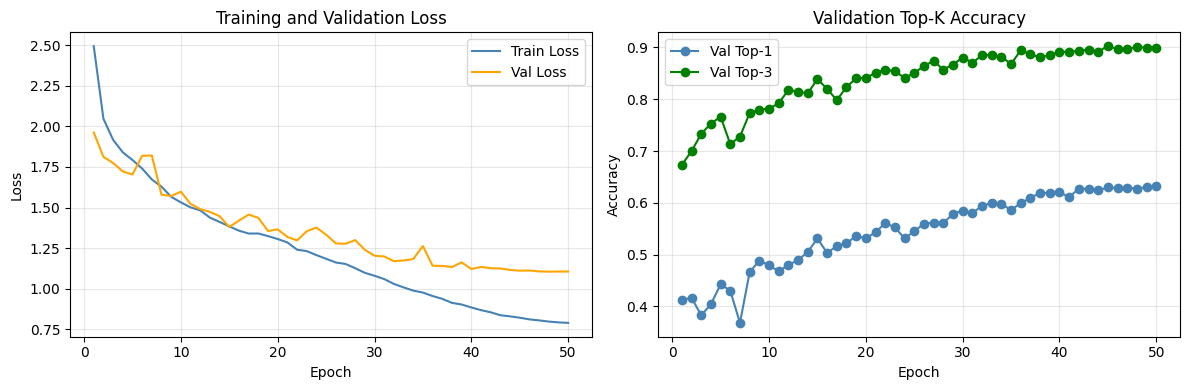

Plot saved.


In [ ]:
# Cell 10 - Training History Plot
import matplotlib.pyplot as plt

epochs     = [h['epoch']      for h in history]
train_loss = [h['train_loss'] for h in history]
val_loss   = [h['val_loss']   for h in history]
val_top1   = [h['val_top1']   for h in history]
val_top3   = [h['val_top3']   for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss, label='Train Loss', color='steelblue')
axes[0].plot(epochs, val_loss,   label='Val Loss',   color='orange')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, val_top1, label='Val Top-1', color='steelblue', marker='o')
axes[1].plot(epochs, val_top3, label='Val Top-3', color='green',     marker='o')
axes[1].set_title('Validation Top-K Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_history.png', dpi=150)
plt.show()
print('Plot saved.')

In [ ]:
# Cell 11 - Download Results
import shutil
from google.colab import files

shutil.copy(f'{SAVE_DIR}/beamllm_results.pkl', '/content/beamllm_results.pkl')
files.download('/content/beamllm_results.pkl')

shutil.copy(f'{SAVE_DIR}/training_history.png', '/content/training_history.png')
files.download('/content/training_history.png')

print('Downloaded: beamllm_results.pkl, training_history.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: beamllm_results.pkl, training_history.png
